## Step 1: Prepare the Ground State

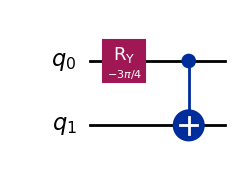

In [ ]:
from qiskit import QuantumCircuit
import numpy as np

# Define parameters
h = 1.0
k = 1.0
theta = -np.arccos(1 / np.sqrt(2) * np.sqrt(1 - h / np.sqrt(h**2 + k**2)))

# Initialize quantum circuit
qc = QuantumCircuit(2)
qc.ry(2 * theta, 0)  # Ground state preparation on qubit 0
qc.cx(0, 1)  # Entanglement with qubit 1
qc.draw('mpl')  # Visualize the circuit

## Step 2: Alice Measures and Deposits Energy

In [2]:
qc.h(0)  # Change to X-basis
qc.measure_all()  # Perform measurement

## Step 3: Simulate Classical Communication

Simulated result for Alice's measurement: 0
Simulated result for Alice's measurement: 1


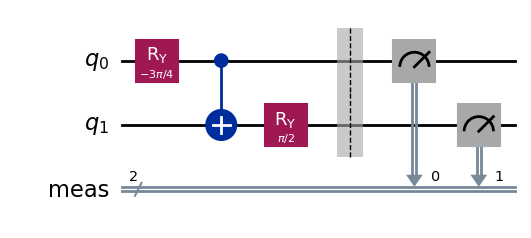

In [4]:
qcs = []
ϕ = np.arctan(k / h)  # Compute phase angle

# Bob's conditional operation based on classical result
for measurement in [0, 1]:  # Simulate both results
    qc = QuantumCircuit(2)
    qc.ry(2 * theta, 0)
    qc.cx(0, 1)
    
    # Simulate Alice's measurement
    if measurement == 0:  # µ = +1
        qc.ry(2 * ϕ, 1)
    else:  # µ = -1
        qc.ry(-2 * ϕ, 1)
    qc.measure_all()
    print(f"Simulated result for Alice's measurement: {measurement}")
    qcs.append(qc)

qcs[0].draw('mpl')
#qcs[1].draw('mpl')

## Step 4: Simulating the Circuit

In [ ]:
# from qiskit_aer import Aer
# from qiskit import execute

#simulator = Aer.get_backend('qasm_simulator')
#job = execute(qc, simulator, shots=1000)
#result = job.result()
#counts = result.get_counts()
#print("Simulation Results:", counts)